# Macro and VD Data preperation
` This notebook is used to properly clean the merged vc and macro data for analsis and later format it in a manner that can be used for regression analysis.  `

**Author**: Ricardo Sanchez

**Date Created:** November 14, 2023

**Notebook:** 01_vc_and_macro_data_preperation

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(r"C:\Users\Ricardo\Documents\Projects\capstone_project\data\cleaned\cleaned_macro\merged_data.csv")

df.head(10)

,Unnamed: 0,quarter_year,year,quarter,deal value ($B),mps_shock,vc_irr,fundraising_activity,dry_powder,heigh_yield_spread,T10Y2Y
0,0,2015-Q1,2015,Q1,6.487186,-0.0662,0.18,45.70,84.66,4.89,1.36
1,1,2015-Q2,2015,Q2,9.105871,-0.0324,0.20,45.70,84.66,4.60,1.55
2,2,2015-Q3,2015,Q3,8.670300,-0.0616,0.15,45.70,84.66,5.54,1.53
3,3,2015-Q4,2015,Q4,7.710457,0.0819,0.11,45.70,84.66,6.40,1.35
4,4,2016-Q1,2016,Q1,8.389389,-0.1054,0.03,50.08,99.15,7.60,1.08
5,5,2016-Q2,2016,Q2,8.749165,-0.0215,-0.02,50.08,99.15,6.33,0.98
6,6,2016-Q3,2016,Q3,7.386611,-0.0076,-0.04,50.08,99.15,5.36,0.84
7,7,2016-Q4,2016,Q4,7.649930,0.0584,-0.01,50.08,99.15,4.63,1.13
8,8,2017-Q1,2017,Q1,8.546432,-0.0650,0.05,49.69,109.97,3.92,1.20
9,9,2017-Q2,2017,Q2,8.578185,0.0493,0.07,49.69,109.97,3.80,0.96


In [7]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [8]:
df.drop(columns=["quarter_year"], inplace=True)

In [19]:
df.drop(columns=["vc_irr"], inplace=True)

In [20]:
df.rename(columns={" deal value ($B) ": "deal_value_billion_usd"}, inplace=True)

df.head()

,year,quarter,deal_value_billion_usd,mps_shock,fundraising_activity,dry_powder,heigh_yield_spread,T10Y2Y,deal_value_percent_change,mps_shock_percentage_change
0,2015,Q1,6.487186,-0.0662,45.70,84.66,4.89,1.36,NaN,NaN
1,2015,Q2,9.105871,-0.0324,45.70,84.66,4.60,1.55,40.367032,-51.057402
2,2015,Q3,8.670300,-0.0616,45.70,84.66,5.54,1.53,-4.783403,90.123457
3,2015,Q4,7.710457,0.0819,45.70,84.66,6.40,1.35,-11.070469,-232.954545
4,2016,Q1,8.389389,-0.1054,50.08,99.15,7.60,1.08,8.805331,-228.693529


In [21]:
df["deal_value_percent_change"] = df['deal_value_billion_usd'].pct_change() * 100

df.head()

,year,quarter,deal_value_billion_usd,mps_shock,fundraising_activity,dry_powder,heigh_yield_spread,T10Y2Y,deal_value_percent_change,mps_shock_percentage_change
0,2015,Q1,6.487186,-0.0662,45.70,84.66,4.89,1.36,NaN,NaN
1,2015,Q2,9.105871,-0.0324,45.70,84.66,4.60,1.55,40.367032,-51.057402
2,2015,Q3,8.670300,-0.0616,45.70,84.66,5.54,1.53,-4.783403,90.123457
3,2015,Q4,7.710457,0.0819,45.70,84.66,6.40,1.35,-11.070469,-232.954545
4,2016,Q1,8.389389,-0.1054,50.08,99.15,7.60,1.08,8.805331,-228.693529


In [22]:
df["mps_shock_percentage_change"] = df['mps_shock'].pct_change() * 100

df.head()

C:\Users\Ricardo\AppData\Local\Temp\ipykernel_2100\1002753658.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["mps_shock_percentage_change"] = df['mps_shock'].pct_change() * 100


,year,quarter,deal_value_billion_usd,mps_shock,fundraising_activity,dry_powder,heigh_yield_spread,T10Y2Y,deal_value_percent_change,mps_shock_percentage_change
0,2015,Q1,6.487186,-0.0662,45.70,84.66,4.89,1.36,NaN,NaN
1,2015,Q2,9.105871,-0.0324,45.70,84.66,4.60,1.55,40.367032,-51.057402
2,2015,Q3,8.670300,-0.0616,45.70,84.66,5.54,1.53,-4.783403,90.123457
3,2015,Q4,7.710457,0.0819,45.70,84.66,6.40,1.35,-11.070469,-232.954545
4,2016,Q1,8.389389,-0.1054,50.08,99.15,7.60,1.08,8.805331,-228.693529


## Data Exploration

In [23]:
%pip install seaborn 

import seaborn as sns
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Ricardo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
df.describe()

,year,deal_value_billion_usd,mps_shock,fundraising_activity,dry_powder,heigh_yield_spread,T10Y2Y,deal_value_percent_change,mps_shock_percentage_change
count,43.000000,43.000000,35.000000,43.000000,43.000000,43.000000,43.000000,42.000000,42.000000
mean,2019.883721,15.312169,0.007329,93.399767,189.549535,4.255116,0.476977,4.049567,-76.675901
std,3.141196,6.607046,0.095107,55.233621,82.671596,1.109821,0.638840,18.046192,287.747324
min,2015.000000,6.487186,-0.405400,45.700000,84.660000,2.800000,-0.770000,-29.188639,-1313.772455
25%,2017.000000,10.390376,-0.026950,49.885000,109.970000,3.480000,0.150000,-9.455345,-99.424042
50%,2020.000000,14.142730,0.017900,77.910000,167.420000,3.980000,0.490000,3.809766,-27.676610
75%,2022.500000,17.515355,0.052400,103.460000,280.725000,4.690000,0.990000,12.584587,8.062880
max,2025.000000,34.025499,0.144700,224.610000,311.250000,7.600000,1.550000,49.007600,416.666667


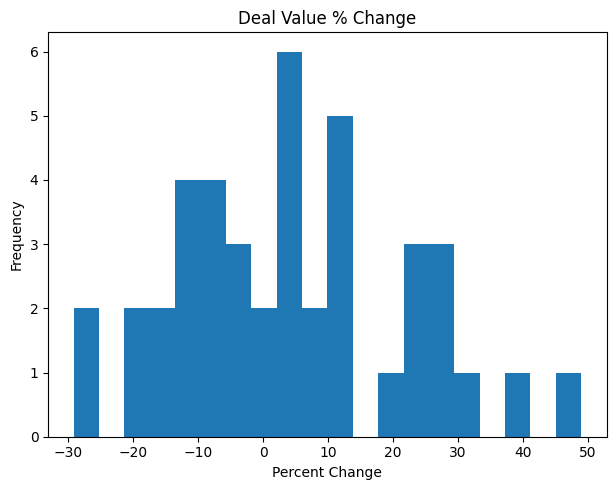

In [25]:
# assuming your DataFrame is named df

plt.figure(figsize=(12,5))

# Histogram for deal_value_percent_change
plt.subplot(1, 2, 1)
plt.hist(df["deal_value_percent_change"].dropna(), bins=20)
plt.title("Deal Value % Change")
plt.xlabel("Percent Change")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

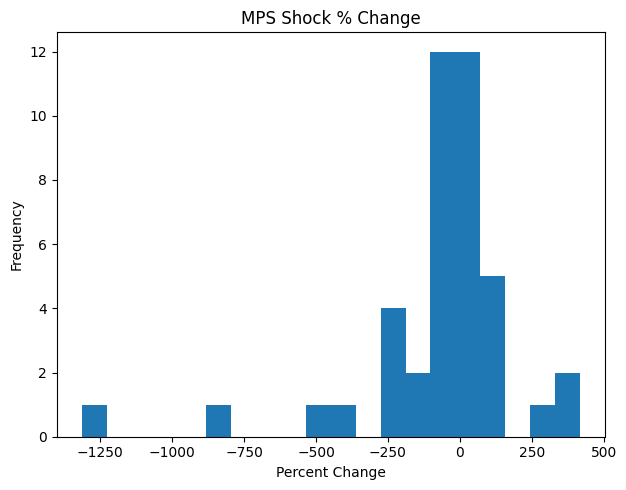

In [26]:
# Histogram for mps_shock_percentage_change
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.hist(df["mps_shock_percentage_change"].dropna(), bins=20)
plt.title("MPS Shock % Change")
plt.xlabel("Percent Change")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()